# Subset Creation From Cloud Storage


In [ ]:
!pip install gcsfs opencv-python tqdm

In [ ]:
from google.colab import auth
auth.authenticate_user()


In [ ]:
!gsutil ls gs://cure-tsd-extract


gs://cure-tsd-extract/data/
gs://cure-tsd-extract/labels/


In [ ]:
import gcsfs, os, re, cv2
from tqdm import tqdm
import tempfile
import os


In [ ]:
def open_video_from_gcs(gcs_path):
    local_path = tempfile.mktemp(suffix=".mp4")
    fs.get(gcs_path, local_path)
    cap = cv2.VideoCapture(local_path)
    return cap, local_path

## Selected Challenges

In [ ]:
CHALLENGE_MAP = {
    "00": "no_challenge",
    "02": "lens_blur",
    "06": "exposure",
    "07": "gaussian_blur",
    "09": "rain"
}

VALID_LEVELS = {"00", "01", "02"}  # no challenge + first two levels


## Predefined Test Sequences by Creators

In [ ]:
TEST_SEQS = {
    "04","05","06","07","08","18","19",
    "21","24","26","31","38","39","41","47"
}


## Filtering the videos

In [ ]:
fs = gcsfs.GCSFileSystem()
BUCKET = "cure-tsd-extract"
VIDEO_DIR = f"{BUCKET}/data/"

pattern = re.compile(r"(01)_(\d{2})_(\d{2})_(\d{2})_(\d{2})\.mp4")

filtered_videos = []

for v in fs.ls(VIDEO_DIR):
    name = os.path.basename(v)
    m = pattern.match(name)
    if not m:
        continue

    _, seq, src, ctype, clevel = m.groups()

    if ctype in CHALLENGE_MAP and clevel in VALID_LEVELS:
        split = "test" if seq in TEST_SEQS else "train"
        filtered_videos.append((v, seq, ctype, clevel, split))

print(f"Selected {len(filtered_videos)} videos")


Selected 441 videos


## Load Annotations

In [ ]:
def load_annotations(seq):
    ann_path = f"{BUCKET}/labels/01_{seq}.txt"
    ann = {}

    with fs.open(ann_path) as f:
        for line in f:
            if isinstance(line, bytes):
                line = line.decode("utf-8")

            line = line.strip()

            # skip header / empty lines
            if not line or not line[0].isdigit():
                continue


            p = line.split("_")

            frame = int(p[0])
            sign_type = int(p[1])
            coords = list(map(int, p[2:]))

            ann.setdefault(frame, []).append([sign_type] + coords)

    return ann


## Frame Extraction and Saving

In [ ]:
OUT_FRAMES = "subset/frames"
OUT_LABELS = "subset/labels"

os.makedirs(f"{OUT_FRAMES}/train", exist_ok=True)
os.makedirs(f"{OUT_FRAMES}/test", exist_ok=True)
os.makedirs(f"{OUT_LABELS}/train", exist_ok=True)
os.makedirs(f"{OUT_LABELS}/test", exist_ok=True)


In [ ]:
FRAME_STRIDE = 1  # keep all annotated frames

for vpath, seq, ctype, clevel, split in tqdm(filtered_videos):
    anns = load_annotations(seq)

    cap, local_video = open_video_from_gcs(vpath)

    if not cap.isOpened():
        print(f"[ERROR] Cannot open video {vpath}")
        continue

    frame_idx = 1
    saved = 0

    while True:
        ret, frame = cap.read()
        if not ret or frame_idx > 300:
            break

        if frame_idx % FRAME_STRIDE != 0:
            frame_idx += 1
            continue

        # keep only frames with annotations
        if frame_idx not in anns:
            frame_idx += 1
            continue

        # ✅ SAVE FRAME AS-IS (NO RESIZE)
        fname = f"01_{seq}_{ctype}_{clevel}_{frame_idx:03d}.jpg"
        cv2.imwrite(f"{OUT_FRAMES}/{split}/{fname}", frame)

        # ✅ SAVE RAW POLYGONS (NO SCALING)
        lbl_path = f"{OUT_LABELS}/{split}/{fname.replace('.jpg','.txt')}"
        with open(lbl_path, "w") as lf:
            for obj in anns[frame_idx]:
                lf.write(" ".join(map(str, obj)) + "\n")

        saved += 1
        frame_idx += 1

    cap.release()
    os.remove(local_video)

    print(f"[SEQ {seq}] saved {saved} frames")


  0%|          | 1/441 [00:05<38:29,  5.25s/it]

[SEQ 01] saved 206 frames


  0%|          | 2/441 [00:09<35:45,  4.89s/it]

[SEQ 01] saved 206 frames


  1%|          | 3/441 [00:14<33:47,  4.63s/it]

...

[SEQ 49] saved 31 frames


100%|█████████▉| 440/441 [28:27<00:02,  2.99s/it]

[SEQ 49] saved 31 frames


100%|██████████| 441/441 [28:30<00:00,  3.88s/it]

[SEQ 49] saved 31 frames


# Faster Lookup Csv

In [ ]:
import pandas as pd

rows = []
for root, _, files in os.walk(OUT_FRAMES):
    for f in files:
        if f.endswith(".jpg"):
            _, seq, ctype, clevel, _ = f.replace(".jpg","").split("_")
            rows.append([os.path.join(root,f), CHALLENGE_MAP[ctype], int(clevel)])

pd.DataFrame(rows, columns=["frame", "challenge", "level"]) \
  .to_csv("subset/classification_labels.csv", index=False)


In [ ]:
import os

train_frames_path = os.path.join(OUT_FRAMES, "test")
num_train_files = len([f for f in os.listdir(train_frames_path) if os.path.isfile(os.path.join(train_frames_path, f))])
print(f"Number of files in {train_frames_path}: {num_train_files}")

Number of files in subset/frames/test: 18918


In [ ]:
!zip -r subset.zip subset


Streaming output truncated to the last 5000 lines.
  adding: subset/labels/test/01_06_00_00_073.txt (deflated 36%)
  adding: subset/labels/test/01_39_07_02_283.txt (deflated 38%)
  adding: subset/labels/test/01_21_00_00_238.txt (deflated 54%)
  adding: subset/labels/test/01_31_09_02_151.txt (deflated 26%)
  adding: subset/labels/test/01_06_02_01_105.txt (deflated 35%)
  adding: subset/labels/test/01_21_00_00_103.txt (deflated 44%)
  adding: subset/labels/test/01_08_06_01_011.txt (deflated 26%)
  adding: subset/labels/test/01_21_06_01_207.txt (deflated 44%)
  adding: subset/labels/test/01_08_06_01_268.txt (deflated 29%)
  adding: subset/labels/test/01_06_00_00_054.txt (deflated 26%)
  adding: subset/labels/test/01_07_02_02_080.txt (deflated 26%)
  adding: subset/labels/test/01_04_07_02_165.txt (deflated 42%)
  adding: subset/labels/test/01_08_06_01_215.txt (deflated 34%)
  adding: subset/labels/test/01_24_02_01_194.txt (deflated 26%)
  adding: subset/labels/test/01_08_07_02_189.txt (def

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!cp subset.zip /content/drive/MyDrive/


## Polygon to Bbox Conversion

In [ ]:
def polygon_to_bbox(obj):
    """
    obj: [cls, llx, lly, lrx, lry, ulx, uly, urx, ury]
    returns: cls, xmin, ymin, xmax, ymax
    """
    cls = obj[0]
    coords = obj[1:]

    xs = coords[::2]
    ys = coords[1::2]

    xmin = min(xs)
    ymin = min(ys)
    xmax = max(xs)
    ymax = max(ys)

    return cls, xmin, ymin, xmax, ymax


## Example Vİsualization

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

IMG_DIR = "subset/frames/train"
LBL_DIR = "subset/labels/train"

img_name = sorted(os.listdir(IMG_DIR))[61]

img = cv2.imread(os.path.join(IMG_DIR, img_name))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

label_path = os.path.join(LBL_DIR, img_name.replace(".jpg", ".txt"))


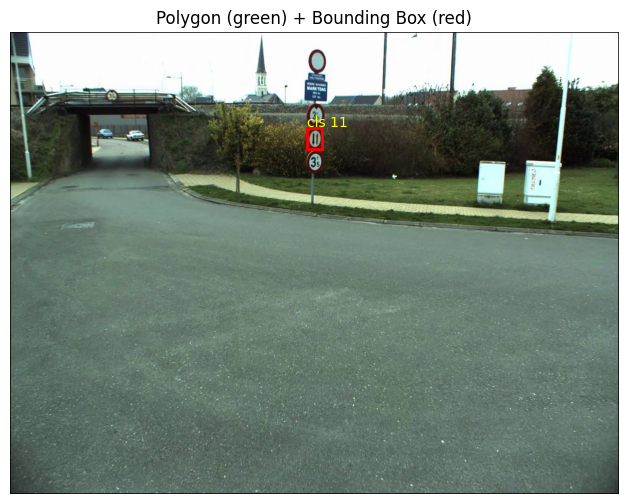

In [ ]:
plt.figure(figsize=(8,6))
plt.imshow(img)

with open(label_path) as f:
    for line in f:
        obj = list(map(int, line.strip().split()))

        # --- POLYGON ---
        coords = obj[1:]
        xs = coords[::2] + [coords[0]]
        ys = coords[1::2] + [coords[1]]
        #plt.plot(xs, ys, "g-", linewidth=2)  # polygon (green)

        # --- BOUNDING BOX ---
        cls, x1, y1, x2, y2 = polygon_to_bbox(obj)
        plt.gca().add_patch(
            plt.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                fill=False,
                edgecolor="red",
                linewidth=2
            )
        )

        plt.text(x1, y1 - 5, f"cls {cls}", color="yellow")

plt.axis("off")
plt.title("Polygon (green) + Bounding Box (red)")
plt.show()
